In [1]:
from langgraph.graph import StateGraph , START , END
from typing import TypedDict , cast
from IPython.display import Image

In [2]:
class batsmanState(TypedDict):
    runs : int
    balls : int
    fours : int
    sixes : int
    
    sr : float
    bpb : float
    boundary_percent : float
    summary : str

In [3]:
def calc_sr(state : batsmanState) :
    sr = (state['runs'] / state['balls']) * 100
    return {"sr": sr}

In [4]:
def calc_bpb(state : batsmanState) :
    bpb = (state['fours'] + state['sixes']) / state['balls']
    return {"bpb": bpb}

In [5]:
def calc_boundary_percent(state : batsmanState) :
    boundary_percent = ((state['fours'] + state['sixes']) / state['runs']) * 100
    return {"boundary_percent": boundary_percent}

In [6]:
def summary(state : batsmanState) -> batsmanState:
    state['summary'] = f"Batsman scored {state['runs']} runs in {state['balls']} balls with a strike rate of {state['sr']:.2f}, boundary percentage of {state['boundary_percent']:.2f}% and boundary per ball of {state['bpb']:.4f}."
    return state

In [7]:
graph = StateGraph(batsmanState)

In [8]:
graph.add_node('calc_sr' , calc_sr)
graph.add_node('calc_bpb' , calc_bpb)
graph.add_node('calc_boundary_percent' , calc_boundary_percent)
graph.add_node('summary' , summary)


In [9]:
graph.add_edge(START , 'calc_sr')
graph.add_edge(START , 'calc_bpb')
graph.add_edge(START , 'calc_boundary_percent')

graph.add_edge('calc_sr' , 'summary')
graph.add_edge('calc_bpb' , 'summary')
graph.add_edge('calc_boundary_percent' , 'summary')

graph.add_edge('summary' , END)

workflow = graph.compile()

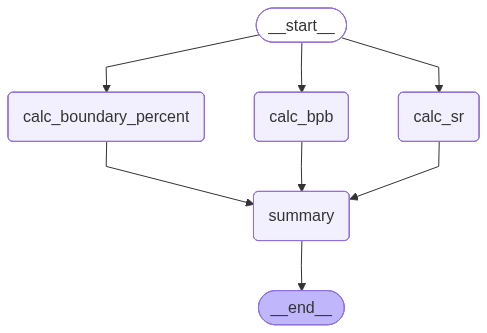

In [10]:
workflow

In [11]:
res = workflow.invoke(cast(batsmanState,{'runs' : 120,'balls' : 100,'fours' : 10,'sixes' : 5}))
print(res)

{'runs': 120, 'balls': 100, 'fours': 10, 'sixes': 5, 'sr': 120.0, 'bpb': 0.15, 'boundary_percent': 12.5, 'summary': 'Batsman scored 120 runs in 100 balls with a strike rate of 120.00, boundary percentage of 12.50% and boundary per ball of 0.1500.'}
